In [30]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [2]:
# The notebook is inside the notebooks/ directory,
# so its parent directory is the AeroVision-Edge project root.

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "visdrone"

TRAIN_DIR = DATASET_ROOT / "VisDrone2019-DET-train"
VAL_DIR = DATASET_ROOT / "VisDrone2019-DET-val"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)

Project root: d:\Data Science\Projects\AeroVision-Edge
Dataset root: d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone
Train directory: d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-train
Validation directory: d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-val


In [3]:
print("Dataset exists:", DATASET_ROOT.exists())
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())

Dataset exists: True
Train exists: True
Validation exists: True


In [5]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added to Python path.")

from src.data.visdrone_annotations import parse_annotation_line

Project root added to Python path.
{'x': 708, 'y': 471, 'width': 74, 'height': 33, 'x_max': 782, 'y_max': 504, 'score': 1, 'category': 4, 'truncation': 0, 'occlusion': 1}


In [6]:
print("TRAIN CONTENTS")
for item in TRAIN_DIR.iterdir():
    print(" -", item)

print("\nVALIDATION CONTENTS")
for item in VAL_DIR.iterdir():
    print(" -", item)

TRAIN CONTENTS
 - d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-train\annotations
 - d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-train\images

VALIDATION CONTENTS
 - d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-val\.DS_Store
 - d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-val\annotations
 - d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-val\images


In [7]:
train_images = list((TRAIN_DIR / "images").glob("*"))
train_annotations = list((TRAIN_DIR / "annotations").glob("*"))

val_images = list((VAL_DIR / "images").glob("*"))
val_annotations = list((VAL_DIR / "annotations").glob("*"))

print("Train images:", len(train_images))
print("Train annotations:", len(train_annotations))

print("Validation images:", len(val_images))
print("Validation annotations:", len(val_annotations))

Train images: 6471
Train annotations: 6471
Validation images: 548
Validation annotations: 548


In [8]:
sample_image_path = (
    TRAIN_DIR
    / "images"
    / "0000002_00005_d_0000014.jpg"
)

print("Sample image:", sample_image_path)
print("Exists:", sample_image_path.exists())

Sample image: d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-train\images\0000002_00005_d_0000014.jpg
Exists: True


In [9]:
sample_annotation = (
    TRAIN_DIR
    / "annotations"
    / f"{sample_image_path.stem}.txt"
)

print("Annotation:", sample_annotation)
print("Exists:", sample_annotation.exists())

Annotation: d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-train\annotations\0000002_00005_d_0000014.txt
Exists: True


In [10]:
with open(sample_annotation, "r") as file:
    annotation_text = file.read()

print(annotation_text)

684,8,273,116,0,0,0,0
406,119,265,70,0,0,0,0
255,22,119,128,0,0,0,0
1,3,209,78,0,0,0,0
708,471,74,33,1,4,0,1
639,425,61,46,1,4,0,0
594,399,64,51,1,4,0,0
562,390,61,38,1,4,0,0
540,372,65,33,1,4,0,1
514,333,68,35,1,4,0,0
501,317,64,31,1,4,0,1
501,299,45,28,1,4,0,1
489,284,48,27,1,4,0,1
463,262,48,29,1,4,0,0
458,252,49,22,1,4,0,1
448,242,45,20,1,4,0,1
442,230,49,19,1,4,0,1
439,214,45,21,1,4,0,1
429,208,42,19,1,4,0,1
420,199,43,20,1,4,0,1
398,188,41,18,1,4,0,1
46,391,14,26,1,2,0,0
421,433,74,44,1,4,0,1
369,346,64,34,1,4,0,0
398,410,72,46,1,4,0,1
394,393,70,36,1,4,0,1
377,364,71,38,1,4,0,0
357,312,58,31,1,4,0,0
359,298,54,22,1,4,0,2
348,283,43,28,1,5,0,1
345,271,52,19,1,4,0,1
340,260,60,18,1,5,0,1
340,250,52,16,1,4,0,1
332,231,54,22,1,5,0,1
323,213,45,25,1,5,0,0
317,195,45,31,1,6,0,1
316,188,36,15,1,4,0,2
308,179,44,17,1,4,0,1
345,163,37,18,1,4,0,0
384,164,26,22,1,4,0,1
43,398,18,17,1,10,0,1
324,167,14,6,1,3,0,0
362,143,30,18,1,4,1,0
310,150,36,15,1,4,0,0
258,375,30,43,1,4,0,2
218,348,18,28

In [11]:
annotations = []

with open(sample_annotation, "r") as file:
    for line in file:
        annotation = parse_annotation_line(line)
        annotations.append(annotation)

print("Number of annotations:", len(annotations))

Number of annotations: 88


In [12]:
print(annotations[0])
print(annotations[4])

{'x': 684, 'y': 8, 'width': 273, 'height': 116, 'x_max': 957, 'y_max': 124, 'score': 0, 'category': 0, 'truncation': 0, 'occlusion': 0}
{'x': 708, 'y': 471, 'width': 74, 'height': 33, 'x_max': 782, 'y_max': 504, 'score': 1, 'category': 4, 'truncation': 0, 'occlusion': 1}


In [13]:
CATEGORY_NAMES = {
    0: "ignored region",
    1: "pedestrian",
    2: "people",
    3: "bicycle",
    4: "car",
    5: "van",
    6: "truck",
    7: "tricycle",
    8: "awning-tricycle",
    9: "bus",
    10: "motor",
    11: "others"
}

In [14]:
category_counts = {}

for annotation in annotations:
    category = annotation["category"]

    if category not in category_counts:
        category_counts[category] = 0

    category_counts[category] += 1

print(category_counts)

{0: 5, 4: 39, 2: 11, 5: 6, 6: 1, 10: 8, 3: 3, 7: 1, 8: 2, 1: 11, 11: 1}


In [15]:
for category, count in category_counts.items():
    print(CATEGORY_NAMES[category], ":", count)

ignored region : 5
car : 39
people : 11
van : 6
truck : 1
motor : 8
bicycle : 3
tricycle : 1
awning-tricycle : 2
pedestrian : 11
others : 1


In [16]:
for annotation in annotations:
    width = annotation["width"]
    height = annotation["height"]
    area = width * height

    print(
        CATEGORY_NAMES[annotation["category"]],
        "width =", width,
        "height =", height,
        "area =", area
    )

ignored region width = 273 height = 116 area = 31668
ignored region width = 265 height = 70 area = 18550
ignored region width = 119 height = 128 area = 15232
ignored region width = 209 height = 78 area = 16302
car width = 74 height = 33 area = 2442
car width = 61 height = 46 area = 2806
car width = 64 height = 51 area = 3264
car width = 61 height = 38 area = 2318
car width = 65 height = 33 area = 2145
car width = 68 height = 35 area = 2380
car width = 64 height = 31 area = 1984
car width = 45 height = 28 area = 1260
car width = 48 height = 27 area = 1296
car width = 48 height = 29 area = 1392
car width = 49 height = 22 area = 1078
car width = 45 height = 20 area = 900
car width = 49 height = 19 area = 931
car width = 45 height = 21 area = 945
car width = 42 height = 19 area = 798
car width = 43 height = 20 area = 860
car width = 41 height = 18 area = 738
people width = 14 height = 26 area = 364
car width = 74 height = 44 area = 3256
car width = 64 height = 34 area = 2176
car width = 72

In [17]:
sample_image = cv2.imread(str(sample_image_path))

print("Image shape:", sample_image.shape)

Image shape: (540, 960, 3)


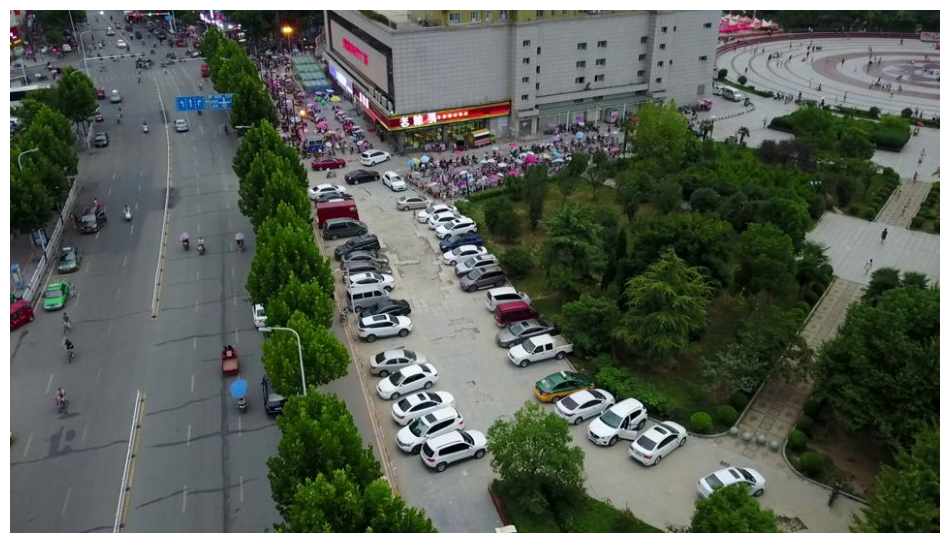

In [18]:
image_rgb = cv2.cvtColor(
    sample_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [19]:
image_with_boxes = sample_image.copy()

for annotation in annotations:
    x1 = annotation["x"]
    y1 = annotation["y"]
    x2 = annotation["x_max"]
    y2 = annotation["y_max"]

    cv2.rectangle(
        image_with_boxes,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

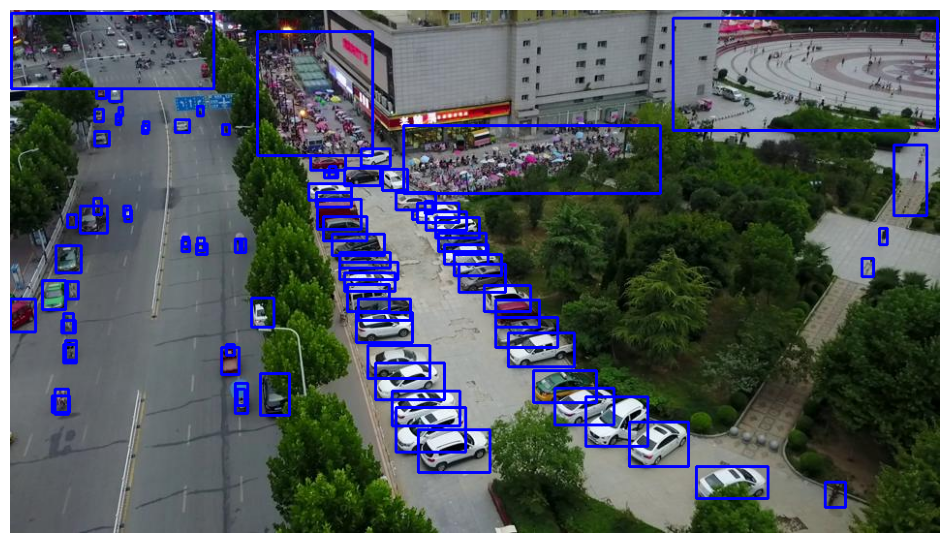

In [20]:
image_with_boxes_rgb = cv2.cvtColor(
    image_with_boxes,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 7))
plt.imshow(image_with_boxes_rgb)
plt.axis("off")
plt.show()

In [21]:
image_with_labels = sample_image.copy()

for annotation in annotations:
    x1 = annotation["x"]
    y1 = annotation["y"]
    x2 = annotation["x_max"]
    y2 = annotation["y_max"]

    category_id = annotation["category"]
    category_name = CATEGORY_NAMES[category_id]

    cv2.rectangle(
        image_with_labels,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image_with_labels,
        category_name,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

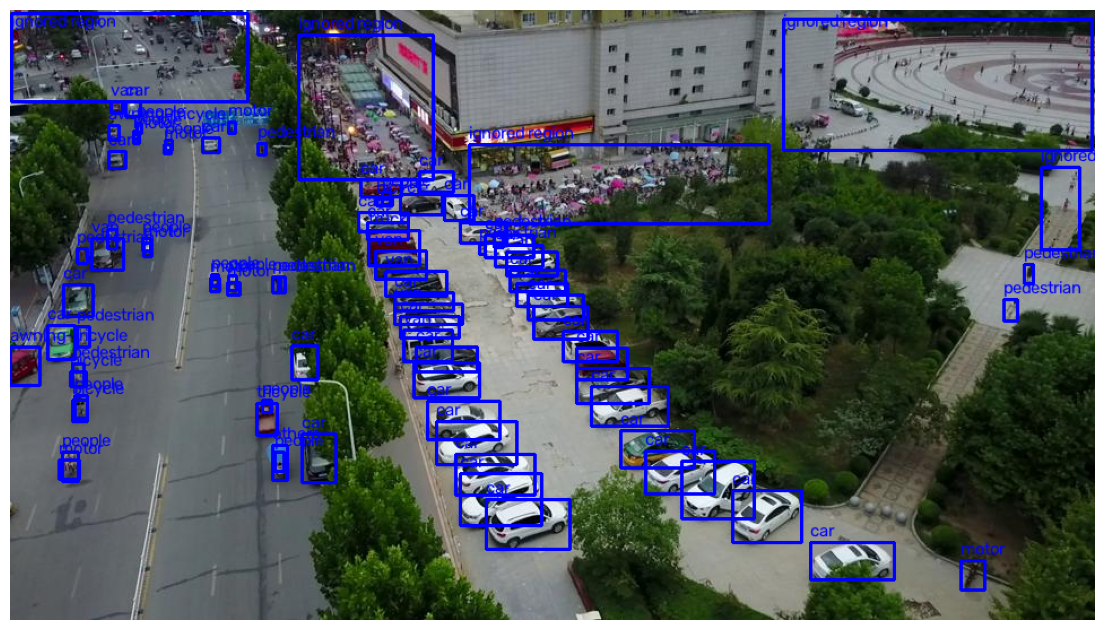

In [22]:
image_with_labels_rgb = cv2.cvtColor(
    image_with_labels,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))
plt.imshow(image_with_labels_rgb)
plt.axis("off")
plt.show()

In [23]:
# Get all training annotation files
train_annotation_files = sorted(
    (TRAIN_DIR / "annotations").glob("*.txt")
)

print("Number of annotation files:", len(train_annotation_files))

Number of annotation files: 6471


In [24]:
total_annotations = 0

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            total_annotations += 1

print("Total annotation lines:", total_annotations)

Total annotation lines: 353550


In [25]:
category_counts = {}

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            category = annotation["category"]

            if category not in category_counts:
                category_counts[category] = 0

            category_counts[category] += 1

In [26]:
for category, count in sorted(category_counts.items()):
    print(
        category,
        CATEGORY_NAMES[category],
        ":",
        count
    )

0 ignored region : 8813
1 pedestrian : 79337
2 people : 27059
3 bicycle : 10480
4 car : 144867
5 van : 24956
6 truck : 12875
7 tricycle : 4812
8 awning-tricycle : 3246
9 bus : 5926
10 motor : 29647
11 others : 1532


In [27]:
ignored_count = category_counts.get(0, 0)

non_ignored_count = total_annotations - ignored_count

print("Total annotations:", total_annotations)
print("Ignored regions:", ignored_count)
print("Non-ignored objects:", non_ignored_count)

Total annotations: 353550
Ignored regions: 8813
Non-ignored objects: 344737


In [31]:
class_distribution = pd.DataFrame(
    [
        {
            "category_id": category,
            "class_name": CATEGORY_NAMES[category],
            "count": count
        }
        for category, count in sorted(category_counts.items())
    ]
)

class_distribution

,category_id,class_name,count
0,0,ignored region,8813
1,1,pedestrian,79337
2,2,people,27059
3,3,bicycle,10480
4,4,car,144867
5,5,van,24956
6,6,truck,12875
7,7,tricycle,4812
8,8,awning-tricycle,3246
9,9,bus,5926


In [32]:
class_distribution["percentage"] = (
    class_distribution["count"]
    / class_distribution["count"].sum()
    * 100
)

class_distribution

,category_id,class_name,count,percentage
0,0,ignored region,8813,2.492717
1,1,pedestrian,79337,22.440107
2,2,people,27059,7.653514
3,3,bicycle,10480,2.964220
4,4,car,144867,40.974968
5,5,van,24956,7.058690
6,6,truck,12875,3.641635
7,7,tricycle,4812,1.361052
8,8,awning-tricycle,3246,0.918116
9,9,bus,5926,1.676142


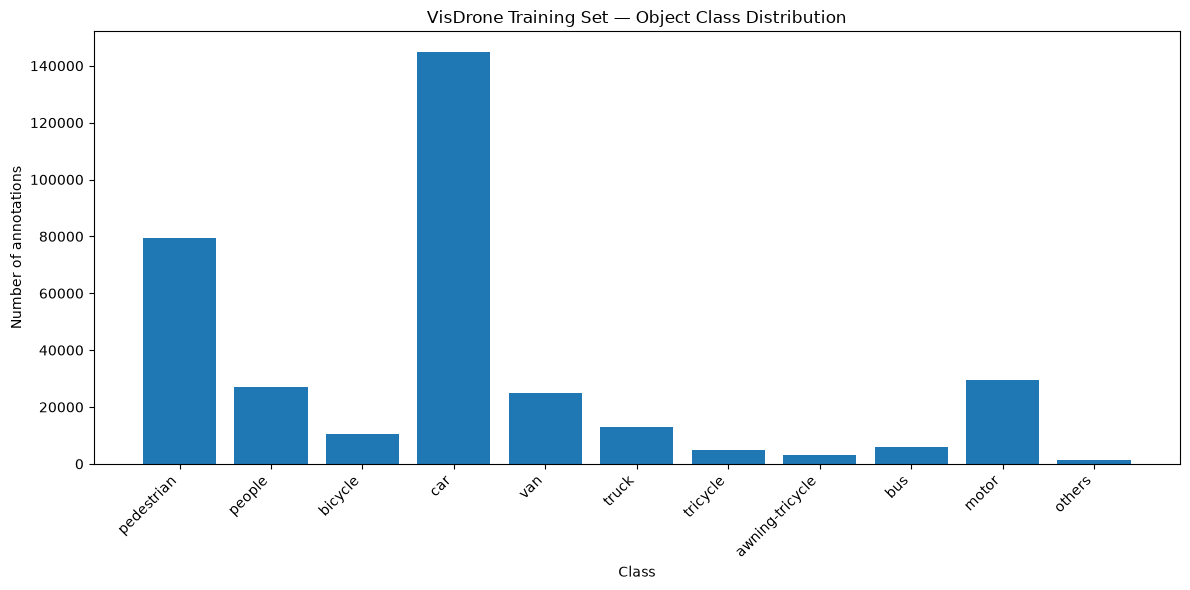

In [33]:
plot_data = class_distribution[
    class_distribution["category_id"] != 0
]

plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["class_name"],
    plot_data["count"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of annotations")
plt.title("VisDrone Training Set — Object Class Distribution")
plt.tight_layout()
plt.show()

In [34]:
objects_per_image = []

for annotation_file in train_annotation_files:
    count = 0

    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            # Count only non-ignored annotations
            if annotation["category"] != 0:
                count += 1

    objects_per_image.append(count)

print("Number of images:", len(objects_per_image))

Number of images: 6471


In [35]:
print("Minimum objects in an image:", min(objects_per_image))
print("Maximum objects in an image:", max(objects_per_image))
print("Average objects per image:", sum(objects_per_image) / len(objects_per_image))

Minimum objects in an image: 1
Maximum objects in an image: 902
Average objects per image: 53.27414619069695


In [36]:
max_objects = max(objects_per_image)

max_index = objects_per_image.index(max_objects)

most_crowded_annotation = train_annotation_files[max_index]

print("Most crowded annotation:", most_crowded_annotation)
print("Number of objects:", max_objects)

Most crowded annotation: d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-train\annotations\0000059_01886_d_0000114.txt
Number of objects: 902


In [37]:
most_crowded_image = (
    TRAIN_DIR
    / "images"
    / f"{most_crowded_annotation.stem}.jpg"
)

print("Image:", most_crowded_image)
print("Exists:", most_crowded_image.exists())

Image: d:\Data Science\Projects\AeroVision-Edge\data\raw\visdrone\VisDrone2019-DET-train\images\0000059_01886_d_0000114.jpg
Exists: True


In [38]:
object_areas = []

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            # Ignore category 0 for object-size analysis
            if annotation["category"] == 0:
                continue

            width = annotation["width"]
            height = annotation["height"]

            area = width * height

            object_areas.append(area)

print("Number of objects:", len(object_areas))
print("Minimum area:", min(object_areas))
print("Maximum area:", max(object_areas))
print("Average area:", sum(object_areas) / len(object_areas))

Number of objects: 344737
Minimum area: 0
Maximum area: 328640
Average area: 2455.161334582595


In [39]:
import numpy as np

print("Median area:", np.median(object_areas))

Median area: 680.0


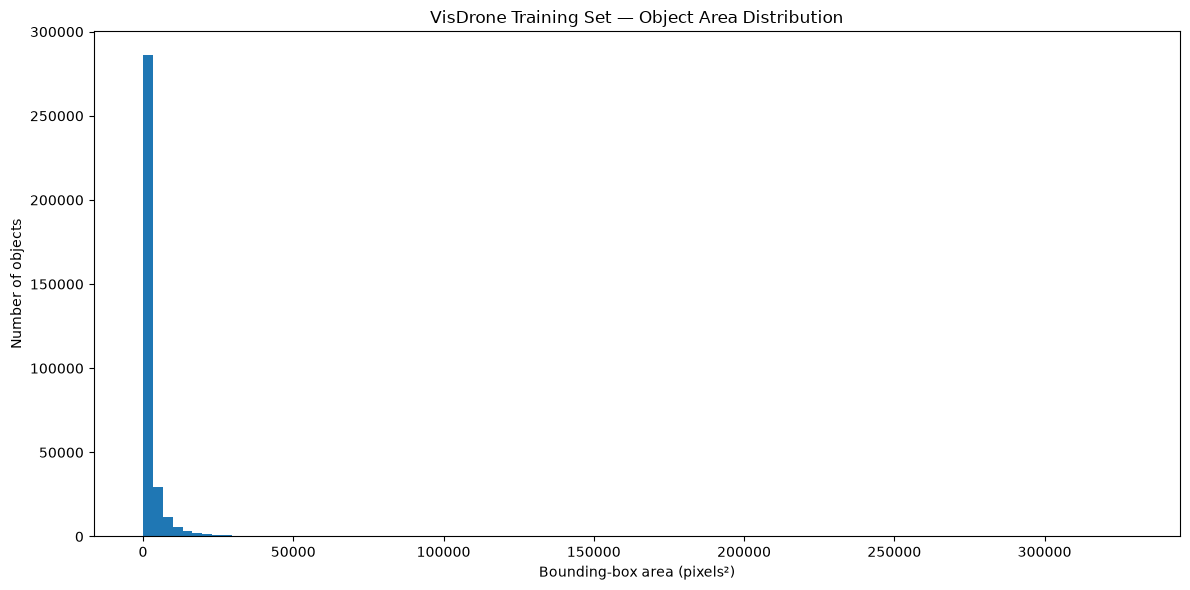

In [40]:
plt.figure(figsize=(12, 6))

plt.hist(
    object_areas,
    bins=100
)

plt.xlabel("Bounding-box area (pixels²)")
plt.ylabel("Number of objects")
plt.title("VisDrone Training Set — Object Area Distribution")
plt.tight_layout()
plt.show()

In [41]:
object_widths = []
object_heights = []

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            if annotation["category"] == 0:
                continue

            object_widths.append(annotation["width"])
            object_heights.append(annotation["height"])

print("Minimum width:", min(object_widths))
print("Maximum width:", max(object_widths))
print("Average width:", sum(object_widths) / len(object_widths))
print("Median width:", np.median(object_widths))

print()

print("Minimum height:", min(object_heights))
print("Maximum height:", max(object_heights))
print("Average height:", sum(object_heights) / len(object_heights))
print("Median height:", np.median(object_heights))

Minimum width: 2
Maximum width: 983
Average width: 38.65643374514485
Median width: 25.0

Minimum height: 0
Maximum height: 790
Average height: 37.463039940592395
Median height: 27.0


In [42]:
zero_area_annotations = []

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line_number, line in enumerate(file, start=1):
            annotation = parse_annotation_line(line)

            if annotation["category"] == 0:
                continue

            width = annotation["width"]
            height = annotation["height"]

            area = width * height

            if area == 0:
                zero_area_annotations.append(
                    {
                        "file": annotation_file,
                        "line": line_number,
                        "annotation": annotation
                    }
                )

print("Zero-area annotations:", len(zero_area_annotations))

Zero-area annotations: 1


In [43]:
for item in zero_area_annotations[:10]:
    print(item)

{'file': WindowsPath('d:/Data Science/Projects/AeroVision-Edge/data/raw/visdrone/VisDrone2019-DET-train/annotations/9999985_00000_d_0000020.txt'), 'line': 12, 'annotation': {'x': 611, 'y': 158, 'width': 4, 'height': 0, 'x_max': 615, 'y_max': 158, 'score': 1, 'category': 4, 'truncation': 0, 'occlusion': 0}}


In [44]:
for item in zero_area_annotations[:10]:
    annotation = item["annotation"]

    print(
        "Width:", annotation["width"],
        "| Height:", annotation["height"],
        "| Category:", annotation["category"],
        "| Class:", CATEGORY_NAMES[annotation["category"]]
    )

Width: 4 | Height: 0 | Category: 4 | Class: car


In [45]:
zero_area_class_counts = {}

for item in zero_area_annotations:
    category = item["annotation"]["category"]

    if category not in zero_area_class_counts:
        zero_area_class_counts[category] = 0

    zero_area_class_counts[category] += 1

for category, count in sorted(zero_area_class_counts.items()):
    print(
        CATEGORY_NAMES[category],
        ":",
        count
    )

car : 1


In [46]:
valid_object_areas = []

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            if annotation["category"] == 0:
                continue

            width = annotation["width"]
            height = annotation["height"]

            area = width * height

            if width > 0 and height > 0:
                valid_object_areas.append(area)

print("Valid objects:", len(valid_object_areas))
print("Minimum area:", min(valid_object_areas))
print("Maximum area:", max(valid_object_areas))
print("Average area:", np.mean(valid_object_areas))
print("Median area:", np.median(valid_object_areas))

Valid objects: 344736
Minimum area: 3
Maximum area: 328640
Average area: 2455.168456442031
Median area: 680.0


In [47]:
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]

for p in percentiles:
    value = np.percentile(valid_object_areas, p)
    print(f"{p}th percentile: {value:.2f} px²")

1th percentile: 24.00 px²
5th percentile: 60.00 px²
10th percentile: 100.00 px²
25th percentile: 247.00 px²
50th percentile: 680.00 px²
75th percentile: 2035.00 px²
90th percentile: 5698.00 px²
95th percentile: 9964.00 px²
99th percentile: 28575.65 px²


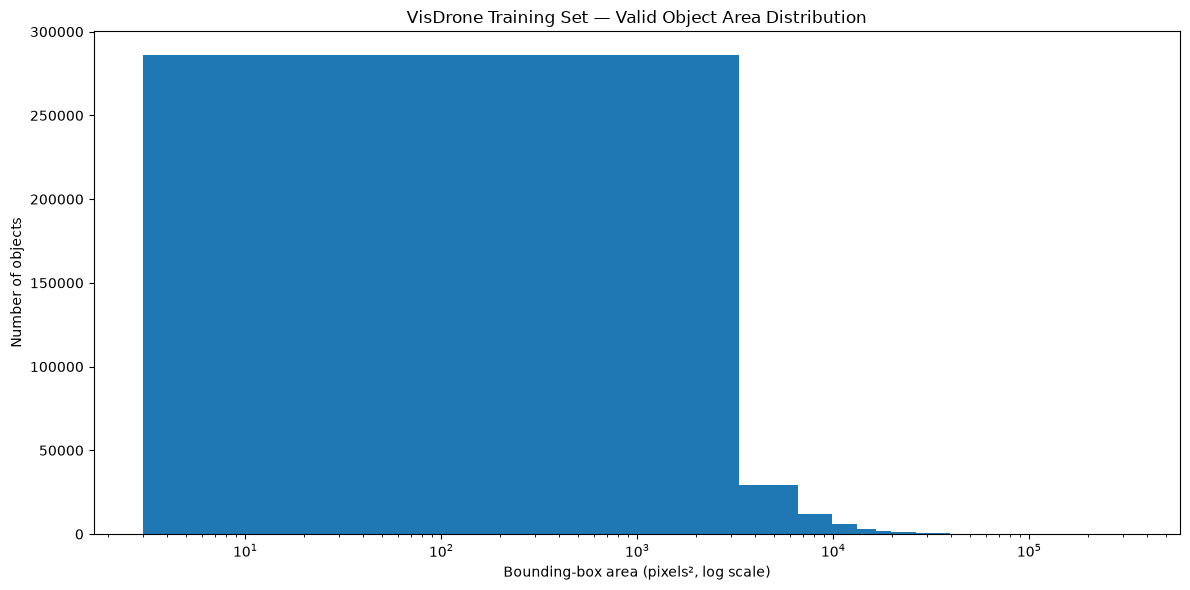

In [48]:
plt.figure(figsize=(12, 6))

plt.hist(
    valid_object_areas,
    bins=100
)

plt.xscale("log")
plt.xlabel("Bounding-box area (pixels², log scale)")
plt.ylabel("Number of objects")
plt.title("VisDrone Training Set — Valid Object Area Distribution")
plt.tight_layout()
plt.show()

In [49]:
aspect_ratios = []

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            if annotation["category"] == 0:
                continue

            width = annotation["width"]
            height = annotation["height"]

            if width > 0 and height > 0:
                aspect_ratio = width / height
                aspect_ratios.append(aspect_ratio)

print("Number of aspect ratios:", len(aspect_ratios))
print("Minimum aspect ratio:", min(aspect_ratios))
print("Maximum aspect ratio:", max(aspect_ratios))
print("Average aspect ratio:", np.mean(aspect_ratios))
print("Median aspect ratio:", np.median(aspect_ratios))

Number of aspect ratios: 344736
Minimum aspect ratio: 0.05357142857142857
Maximum aspect ratio: 12.541666666666666
Average aspect ratio: 1.0968793208270664
Median aspect ratio: 0.9122807017543859


In [50]:
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    value = np.percentile(aspect_ratios, p)
    print(f"{p}th percentile: {value:.3f}")

1th percentile: 0.286
5th percentile: 0.364
10th percentile: 0.417
25th percentile: 0.566
50th percentile: 0.912
75th percentile: 1.471
90th percentile: 2.111
95th percentile: 2.405
99th percentile: 2.969


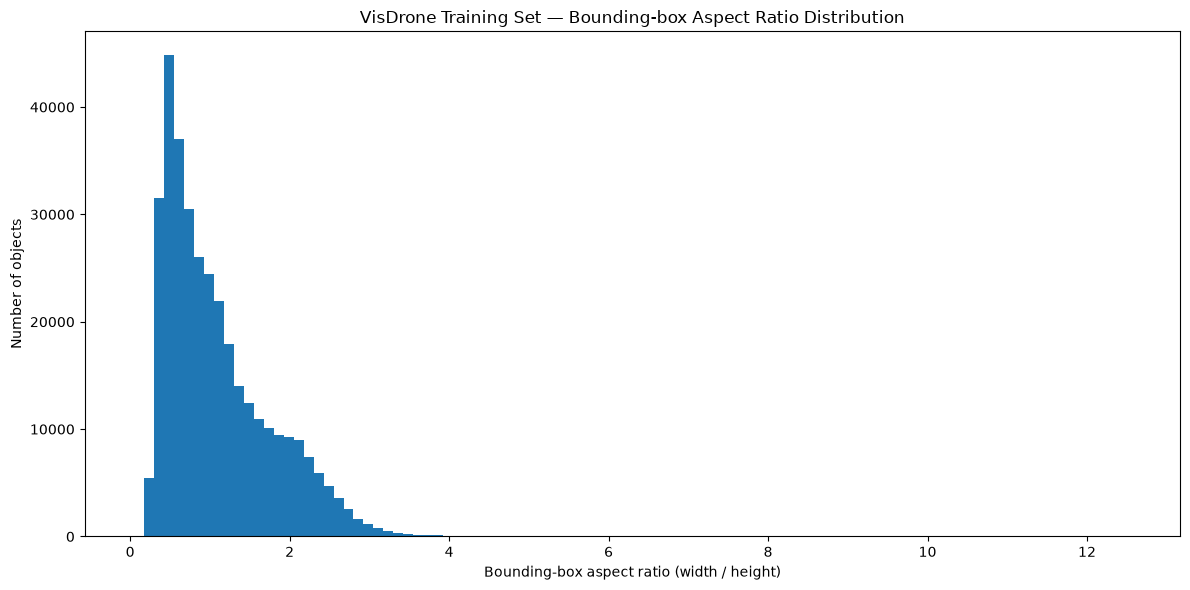

In [51]:
plt.figure(figsize=(12, 6))

plt.hist(
    aspect_ratios,
    bins=100
)

plt.xlabel("Bounding-box aspect ratio (width / height)")
plt.ylabel("Number of objects")
plt.title("VisDrone Training Set — Bounding-box Aspect Ratio Distribution")
plt.tight_layout()
plt.show()

In [52]:
occlusion_counts = {}

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            if annotation["category"] == 0:
                continue

            occlusion = annotation["occlusion"]

            if occlusion not in occlusion_counts:
                occlusion_counts[occlusion] = 0

            occlusion_counts[occlusion] += 1

print(occlusion_counts)

{1: 142873, 0: 168060, 2: 33804}


In [53]:
occlusion_names = {
    0: "No occlusion",
    1: "Partial occlusion",
    2: "Heavy occlusion"
}

for occlusion, count in sorted(occlusion_counts.items()):
    print(
        occlusion_names[occlusion],
        ":",
        count
    )

No occlusion : 168060
Partial occlusion : 142873
Heavy occlusion : 33804


In [54]:
total_objects = sum(occlusion_counts.values())

for occlusion, count in sorted(occlusion_counts.items()):
    percentage = count / total_objects * 100

    print(
        occlusion_names[occlusion],
        ":",
        f"{count:,}",
        f"({percentage:.2f}%)"
    )

No occlusion : 168,060 (48.75%)
Partial occlusion : 142,873 (41.44%)
Heavy occlusion : 33,804 (9.81%)


In [55]:
truncation_counts = {}

for annotation_file in train_annotation_files:
    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            if annotation["category"] == 0:
                continue

            truncation = annotation["truncation"]

            if truncation not in truncation_counts:
                truncation_counts[truncation] = 0

            truncation_counts[truncation] += 1

print(truncation_counts)

{0: 331281, 1: 13456}


In [56]:
truncation_names = {
    0: "No truncation",
    1: "Partial truncation"
}

for truncation, count in sorted(truncation_counts.items()):
    percentage = count / total_objects * 100

    print(
        truncation_names[truncation],
        ":",
        f"{count:,}",
        f"({percentage:.2f}%)"
    )

No truncation : 331,281 (96.10%)
Partial truncation : 13,456 (3.90%)


In [57]:
# Master annotation table

annotation_records = []

for annotation_file in train_annotation_files:
    image_id = annotation_file.stem

    with open(annotation_file, "r") as file:
        for line in file:
            annotation = parse_annotation_line(line)

            # Ignore category 0 for object-level analysis
            if annotation["category"] == 0:
                continue

            width = annotation["width"]
            height = annotation["height"]

            # Skip the single degenerate bounding box we discovered
            if width <= 0 or height <= 0:
                continue

            area = width * height
            aspect_ratio = width / height

            annotation_records.append(
                {
                    "image_id": image_id,
                    "category_id": annotation["category"],
                    "class_name": CATEGORY_NAMES[annotation["category"]],
                    "x": annotation["x"],
                    "y": annotation["y"],
                    "width": width,
                    "height": height,
                    "x_max": annotation["x_max"],
                    "y_max": annotation["y_max"],
                    "area": area,
                    "aspect_ratio": aspect_ratio,
                    "truncation": annotation["truncation"],
                    "occlusion": annotation["occlusion"],
                }
            )

print("Number of records:", len(annotation_records))

Number of records: 344736


In [58]:
annotations_df = pd.DataFrame(annotation_records)

print("Rows:", len(annotations_df))
print("Columns:", len(annotations_df.columns))

Rows: 344736
Columns: 13


In [59]:
annotations_df.head()

,image_id,category_id,class_name,x,y,width,height,x_max,y_max,area,aspect_ratio,truncation,occlusion
0,0000002_00005_d_0000014,4,car,708,471,74,33,782,504,2442,2.242424,0,1
1,0000002_00005_d_0000014,4,car,639,425,61,46,700,471,2806,1.326087,0,0
2,0000002_00005_d_0000014,4,car,594,399,64,51,658,450,3264,1.254902,0,0
3,0000002_00005_d_0000014,4,car,562,390,61,38,623,428,2318,1.605263,0,0
4,0000002_00005_d_0000014,4,car,540,372,65,33,605,405,2145,1.969697,0,1


In [60]:
annotations_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344736 entries, 0 to 344735
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   image_id      344736 non-null  str    
 1   category_id   344736 non-null  int64  
 2   class_name    344736 non-null  str    
 3   x             344736 non-null  int64  
 4   y             344736 non-null  int64  
 5   width         344736 non-null  int64  
 6   height        344736 non-null  int64  
 7   x_max         344736 non-null  int64  
 8   y_max         344736 non-null  int64  
 9   area          344736 non-null  int64  
 10  aspect_ratio  344736 non-null  float64
 11  truncation    344736 non-null  int64  
 12  occlusion     344736 non-null  int64  
dtypes: float64(1), int64(10), str(2)
memory usage: 34.2 MB


In [61]:
annotations_df.describe()

,category_id,x,y,width,height,x_max,y_max,area,aspect_ratio,truncation,occlusion
count,344736.000000,344736.000000,344736.000000,344736.000000,344736.000000,344736.000000,344736.000000,344736.000000,344736.000000,344736.000000,344736.000000
mean,3.981879,741.991367,397.406186,38.656534,37.463149,780.647902,434.869335,2455.168456,1.096879,0.039033,0.610557
std,2.580085,381.685149,269.756868,40.632915,34.056516,384.344923,282.647718,6607.189092,0.668517,0.193673,0.658706
min,1.000000,0.000000,0.000000,2.000000,1.000000,5.000000,3.000000,3.000000,0.053571,0.000000,0.000000
25%,2.000000,474.000000,188.000000,13.000000,17.000000,509.000000,214.000000,247.000000,0.566038,0.000000,0.000000
50%,4.000000,726.000000,352.000000,25.000000,27.000000,758.000000,386.000000,680.000000,0.912281,0.000000,1.000000
75%,4.000000,994.000000,569.000000,49.000000,46.000000,1031.000000,611.000000,2035.000000,1.470588,0.000000,1.000000
max,11.000000,1993.000000,1488.000000,983.000000,790.000000,2000.000000,1500.000000,328640.000000,12.541667,1.000000,2.000000


In [62]:
print("Objects:", len(annotations_df))

Objects: 344736


In [63]:
print(
    annotations_df["class_name"].value_counts()
)

class_name
car                144866
pedestrian          79337
motor               29647
people              27059
van                 24956
truck               12875
bicycle             10480
bus                  5926
tricycle             4812
awning-tricycle      3246
others               1532
Name: count, dtype: int64


In [64]:
print(
    "Median area:",
    annotations_df["area"].median()
)

Median area: 680.0


In [65]:
print(
    "Median width:",
    annotations_df["width"].median()
)

Median width: 25.0


In [66]:
print(
    "Median height:",
    annotations_df["height"].median()
)

Median height: 27.0


In [67]:
class_counts_df = (
    annotations_df["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

print(class_counts_df)

class_name
car                144866
pedestrian          79337
motor               29647
people              27059
van                 24956
truck               12875
bicycle             10480
bus                  5926
tricycle             4812
awning-tricycle      3246
others               1532
Name: count, dtype: int64


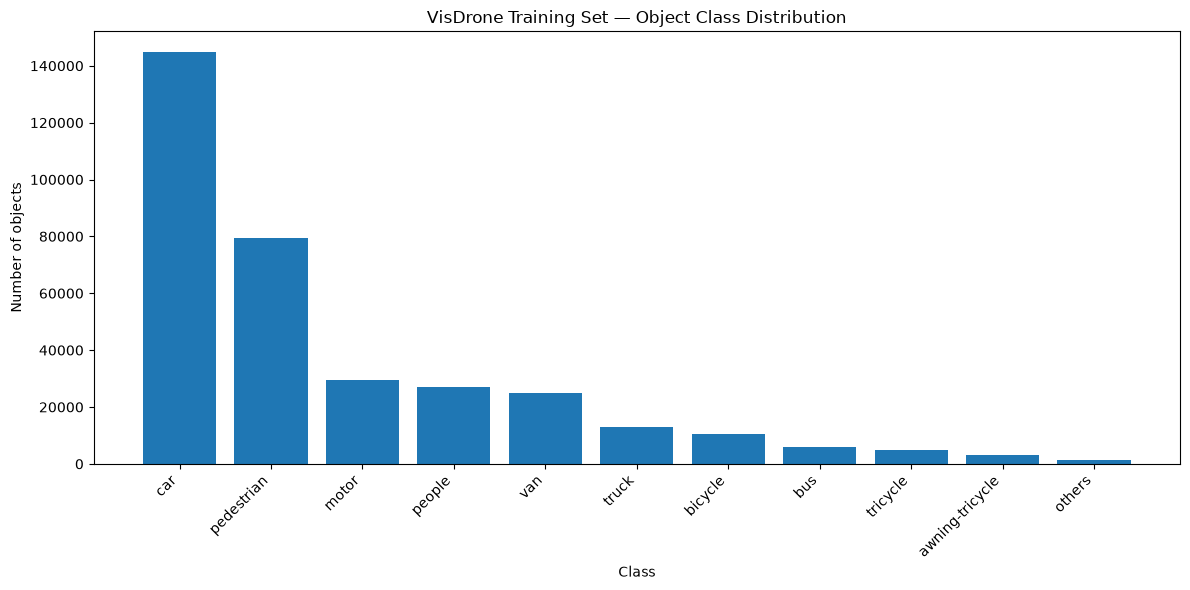

In [68]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_counts_df.index,
    class_counts_df.values
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of objects")
plt.title("VisDrone Training Set — Object Class Distribution")
plt.tight_layout()
plt.show()

In [69]:
output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "visdrone_annotations.csv"
)

annotations_df.to_csv(
    output_path,
    index=False
)

print("Saved to:", output_path)

Saved to: d:\Data Science\Projects\AeroVision-Edge\data\processed\visdrone_annotations.csv


In [70]:
class_size_summary = (
    annotations_df
    .groupby("class_name")
    .agg(
        object_count=("area", "count"),
        median_area=("area", "median"),
        mean_area=("area", "mean"),
        median_width=("width", "median"),
        median_height=("height", "median")
    )
    .sort_values("median_area")
)

class_size_summary

,object_count,median_area,mean_area,median_width,median_height
class_name,,,,,
people,27059,273.0,591.580324,13.0,20.0
pedestrian,79337,315.0,712.287798,13.0,25.0
motor,29647,512.0,993.918204,22.0,23.0
bicycle,10480,612.0,1221.883397,24.0,26.0
car,144866,1104.0,3289.262028,38.0,29.0
tricycle,4812,1188.0,2547.023483,36.0,33.0
awning-tricycle,3246,1320.0,2905.229513,36.0,36.0
van,24956,1352.0,4113.737538,40.0,34.0
others,1532,1556.0,3970.176240,39.0,39.0


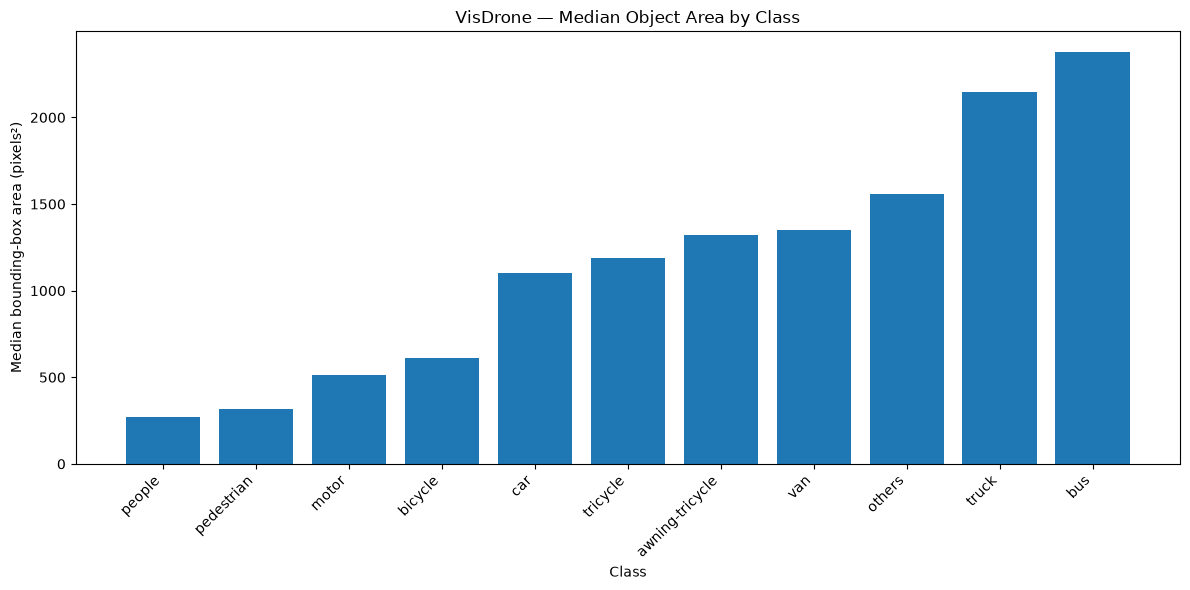

In [71]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_size_summary.index,
    class_size_summary["median_area"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Median bounding-box area (pixels²)")
plt.title("VisDrone — Median Object Area by Class")
plt.tight_layout()
plt.show()

In [72]:
image_dimensions = []

for image_path in train_images:
    with Image.open(image_path) as image:
        width, height = image.size

    image_dimensions.append(
        {
            "image_id": image_path.stem,
            "image_width": width,
            "image_height": height
        }
    )

image_dimensions_df = pd.DataFrame(image_dimensions)

image_dimensions_df.head()

,image_id,image_width,image_height
0,0000002_00005_d_0000014,960,540
1,0000002_00448_d_0000015,960,540
2,0000003_00231_d_0000016,960,540
3,0000007_04999_d_0000036,1360,765
4,0000007_05499_d_0000037,1360,765


In [73]:
print(
    "Number of images:",
    len(image_dimensions_df)
)

Number of images: 6471


In [74]:
image_dimensions_df[
    ["image_width", "image_height"]
].describe()

,image_width,image_height
count,6471.000000,6471.000000
mean,1519.889507,1002.397002
std,269.521521,235.063535
min,480.000000,360.000000
25%,1400.000000,788.000000
50%,1400.000000,1050.000000
75%,1916.000000,1078.000000
max,2000.000000,1500.000000


In [75]:
resolution_counts = (
    image_dimensions_df
    .groupby(["image_width", "image_height"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

resolution_counts.head(20)

,image_width,image_height,image_count
7,1400,1050,2498
6,1400,788,1299
10,2000,1500,772
3,1360,765,743
8,1916,1078,537
9,1920,1080,339
1,960,540,250
5,1398,1048,30
0,480,360,1
2,1344,756,1


In [76]:
annotations_df = annotations_df.merge(
    image_dimensions_df,
    on="image_id",
    how="left"
)

In [77]:
print(annotations_df.shape)

(344736, 15)


In [78]:
annotations_df[
    [
        "image_id",
        "width",
        "height",
        "image_width",
        "image_height"
    ]
].head()

,image_id,width,height,image_width,image_height
0,0000002_00005_d_0000014,74,33,960,540
1,0000002_00005_d_0000014,61,46,960,540
2,0000002_00005_d_0000014,64,51,960,540
3,0000002_00005_d_0000014,61,38,960,540
4,0000002_00005_d_0000014,65,33,960,540


In [79]:
annotations_df["image_area"] = (
    annotations_df["image_width"]
    * annotations_df["image_height"]
)

In [80]:
annotations_df["relative_area"] = (
    annotations_df["area"]
    / annotations_df["image_area"]
)

In [81]:
annotations_df["relative_area_percent"] = (
    annotations_df["relative_area"] * 100
)

In [82]:
annotations_df["relative_area_percent"].describe()

count    344736.000000
mean          0.153963
std           0.386028
min           0.000145
25%           0.017132
50%           0.046296
75%           0.134564
max          30.296232
Name: relative_area_percent, dtype: float64

In [83]:
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    value = np.percentile(
        annotations_df["relative_area_percent"],
        p
    )

    print(f"{p}th percentile: {value:.6f}%")

1th percentile: 0.001736%
5th percentile: 0.004286%
10th percentile: 0.006944%
25th percentile: 0.017132%
50th percentile: 0.046296%
75th percentile: 0.134564%
90th percentile: 0.361905%
95th percentile: 0.633601%
99th percentile: 1.692834%


In [84]:
annotations_df["relative_width"] = (
    annotations_df["width"]
    / annotations_df["image_width"]
)

In [85]:
annotations_df["relative_height"] = (
    annotations_df["height"]
    / annotations_df["image_height"]
)

In [86]:
print(
    annotations_df[
        [
            "relative_width",
            "relative_height"
        ]
    ].describe()
)

       relative_width  relative_height
count   344736.000000    344736.000000
mean         0.025222         0.037719
std          0.025886         0.032655
min          0.001000         0.000928
25%          0.009000         0.017143
50%          0.016912         0.027919
75%          0.031878         0.046667
max          0.543382         0.653061


In [87]:
size_bins = annotations_df["relative_area"].quantile(
    [0.10, 0.50, 0.90]
)

print(size_bins)

0.1    0.000069
0.5    0.000463
0.9    0.003619
Name: relative_area, dtype: float64


In [88]:
annotations_df["size_group"] = pd.cut(
    annotations_df["relative_area"],
    bins=[
        -np.inf,
        size_bins[0.10],
        size_bins[0.50],
        size_bins[0.90],
        np.inf
    ],
    labels=[
        "smallest 10%",
        "10-50%",
        "50-90%",
        "largest 10%"
    ]
)

In [89]:
size_group_counts = (
    annotations_df["size_group"]
    .value_counts()
    .sort_index()
)

size_group_counts

size_group
smallest 10%     34733
10-50%          137728
50-90%          137811
largest 10%      34464
Name: count, dtype: int64

In [92]:
class_relative_size = (
    annotations_df
    .groupby("class_name", observed=True)
    .agg(
        object_count=("relative_area", "count"),
        median_relative_area=("relative_area", "median"),
        median_relative_width=("relative_width", "median"),
        median_relative_height=("relative_height", "median")
    )
    .sort_values("median_relative_area")
)

class_relative_size

,object_count,median_relative_area,median_relative_width,median_relative_height
class_name,,,,
people,27059,0.000189,0.008824,0.020952
pedestrian,79337,0.000230,0.008571,0.026667
motor,29647,0.000347,0.014286,0.023810
bicycle,10480,0.000351,0.014583,0.024074
car,144866,0.000731,0.025000,0.029188
awning-tricycle,3246,0.000840,0.022443,0.036601
tricycle,4812,0.000868,0.023571,0.035294
van,24956,0.000910,0.026000,0.035333
others,1532,0.001062,0.025714,0.040816


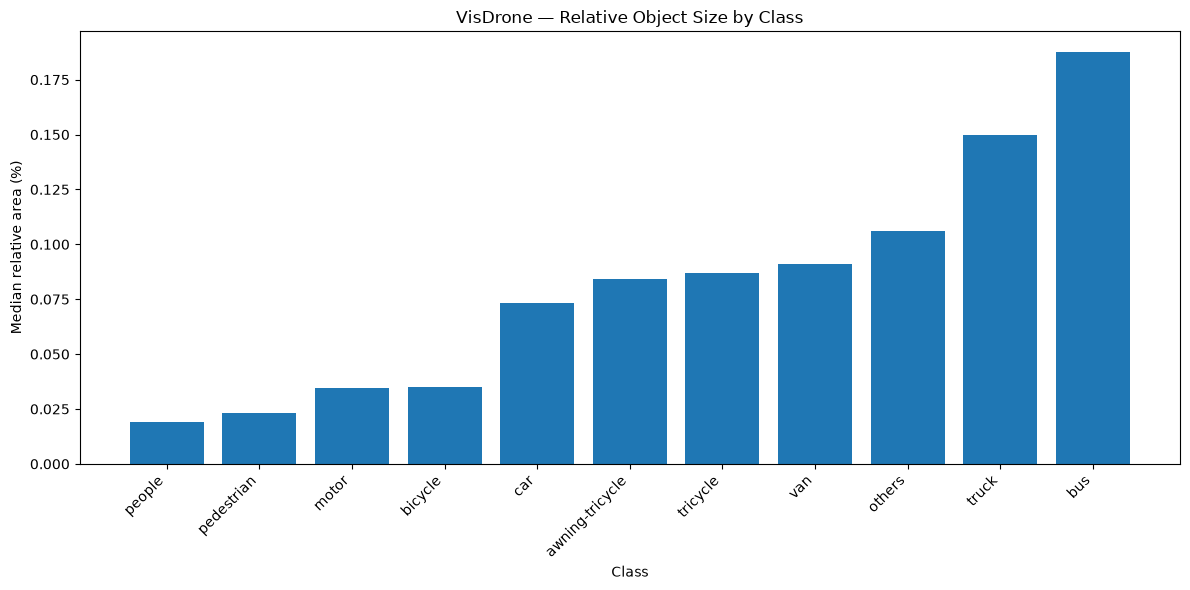

In [91]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_relative_size.index,
    class_relative_size["median_relative_area"] * 100
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Median relative area (%)")
plt.title("VisDrone — Relative Object Size by Class")
plt.tight_layout()
plt.show()

In [93]:
size_occlusion = pd.crosstab(
    annotations_df["size_group"],
    annotations_df["occlusion"]
)

size_occlusion

occlusion,0,1,2
size_group,,,
smallest 10%,18816,13183,2734
10-50%,62257,60722,14749
50-90%,66354,57251,14206
largest 10%,20632,11717,2115


In [94]:
size_occlusion_percent = pd.crosstab(
    annotations_df["size_group"],
    annotations_df["occlusion"],
    normalize="index"
) * 100

size_occlusion_percent

occlusion,0,1,2
size_group,,,
smallest 10%,54.173265,37.955259,7.871477
10-50%,45.202864,44.088348,10.708788
50-90%,48.148551,41.543128,10.308321
largest 10%,59.865367,33.997795,6.136838


In [95]:
size_occlusion_percent.columns = [
    "No occlusion",
    "Partial occlusion",
    "Heavy occlusion"
]

size_occlusion_percent

,No occlusion,Partial occlusion,Heavy occlusion
size_group,,,
smallest 10%,54.173265,37.955259,7.871477
10-50%,45.202864,44.088348,10.708788
50-90%,48.148551,41.543128,10.308321
largest 10%,59.865367,33.997795,6.136838


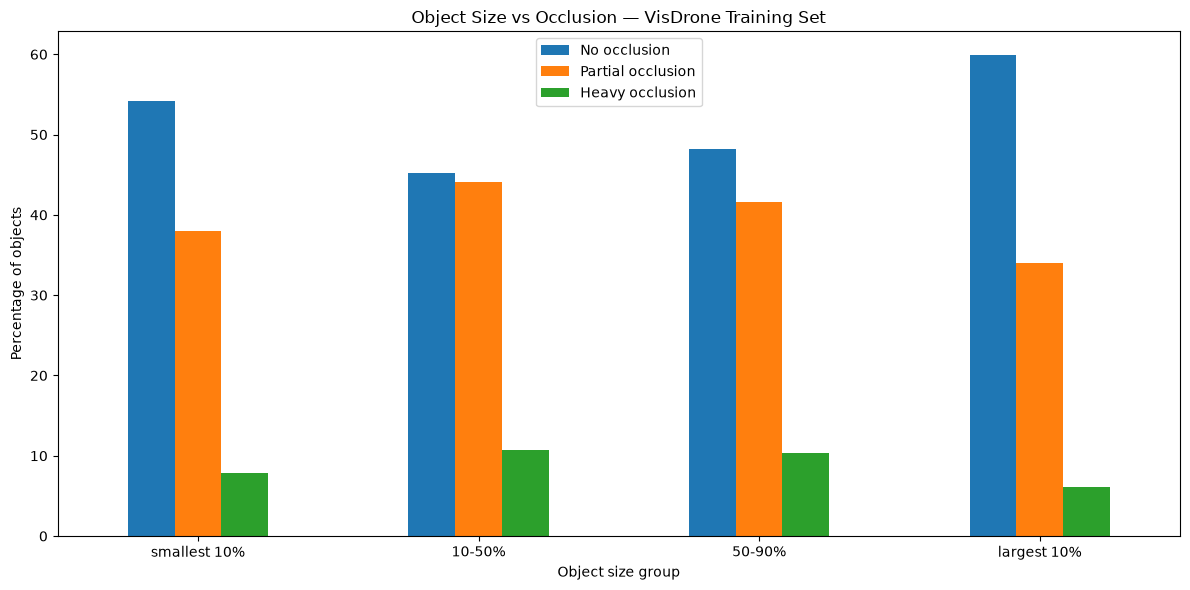

In [96]:
size_occlusion_percent.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Object size group")
plt.ylabel("Percentage of objects")
plt.title("Object Size vs Occlusion — VisDrone Training Set")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [97]:
image_crowding_df = pd.DataFrame({
    "image_id": [path.stem for path in train_annotation_files],
    "object_count": objects_per_image
})

image_crowding_df.head()

,image_id,object_count
0,0000002_00005_d_0000014,83
1,0000002_00448_d_0000015,86
2,0000003_00231_d_0000016,39
3,0000007_04999_d_0000036,59
4,0000007_05499_d_0000037,62


In [98]:
image_crowding_df.describe()

,object_count
count,6471.000000
mean,53.274146
std,43.926287
min,1.000000
25%,24.000000
50%,42.000000
75%,70.000000
max,902.000000


In [99]:
crowding_bins = image_crowding_df["object_count"].quantile(
    [0.25, 0.50, 0.75]
)

print(crowding_bins)

0.25    24.0
0.50    42.0
0.75    70.0
Name: object_count, dtype: float64


In [100]:
image_crowding_df["crowding_group"] = pd.cut(
    image_crowding_df["object_count"],
    bins=[
        -np.inf,
        crowding_bins[0.25],
        crowding_bins[0.50],
        crowding_bins[0.75],
        np.inf
    ],
    labels=[
        "lowest 25%",
        "25-50%",
        "50-75%",
        "highest 25%"
    ]
)

image_crowding_df["crowding_group"].value_counts().sort_index()

crowding_group
lowest 25%     1681
25-50%         1589
50-75%         1598
highest 25%    1603
Name: count, dtype: int64

In [101]:
annotations_with_crowding = annotations_df.merge(
    image_crowding_df[
        [
            "image_id",
            "object_count",
            "crowding_group"
        ]
    ],
    on="image_id",
    how="left"
)

In [103]:
crowding_size_summary = (
    annotations_with_crowding
    .groupby("crowding_group", observed=True)
    .agg(
        image_count=("image_id", "nunique"),
        object_count=("image_id", "count"),
        median_area=("area", "median"),
        median_relative_area=("relative_area", "median"),
        median_width=("width", "median"),
        median_height=("height", "median")
    )
)

crowding_size_summary

,image_count,object_count,median_area,median_relative_area,median_width,median_height
crowding_group,,,,,,
lowest 25%,1681,25500,1520.0,0.001088,38.0,41.0
25-50%,1589,53074,1089.0,0.000734,33.0,34.0
50-75%,1598,87900,805.0,0.000552,28.0,29.0
highest 25%,1603,178262,513.0,0.000347,22.0,24.0


In [104]:
eda_summary = {
    "training_images": len(train_images),
    "valid_objects": len(annotations_df),
    "ignored_regions": ignored_count,
    "zero_area_objects": len(zero_area_annotations),
    "average_objects_per_image": np.mean(objects_per_image),
    "maximum_objects_per_image": max(objects_per_image),
    "median_object_area": annotations_df["area"].median(),
    "median_object_width": annotations_df["width"].median(),
    "median_object_height": annotations_df["height"].median(),
    "median_relative_area": annotations_df["relative_area"].median(),
    "partial_or_heavy_occlusion_percent": (
        annotations_df["occlusion"].isin([1, 2]).mean() * 100
    ),
    "partial_truncation_percent": (
        annotations_df["truncation"].eq(1).mean() * 100
    ),
}

eda_summary_df = pd.DataFrame(
    list(eda_summary.items()),
    columns=["metric", "value"]
)

eda_summary_df

,metric,value
0,training_images,6471.000000
1,valid_objects,344736.000000
2,ignored_regions,8813.000000
3,zero_area_objects,1.000000
4,average_objects_per_image,53.274146
5,maximum_objects_per_image,902.000000
6,median_object_area,680.000000
7,median_object_width,25.000000
8,median_object_height,27.000000
9,median_relative_area,0.000463


In [105]:
summary_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "eda_summary.csv"
)

eda_summary_df.to_csv(
    summary_path,
    index=False
)

print("Saved to:", summary_path)

Saved to: d:\Data Science\Projects\AeroVision-Edge\data\processed\eda_summary.csv


In [106]:
crowding_occlusion = pd.crosstab(
    annotations_with_crowding["crowding_group"],
    annotations_with_crowding["occlusion"],
    normalize="index"
) * 100

crowding_occlusion.columns = [
    "No occlusion",
    "Partial occlusion",
    "Heavy occlusion"
]

crowding_occlusion

,No occlusion,Partial occlusion,Heavy occlusion
crowding_group,,,
lowest 25%,63.160784,30.827451,6.011765
25-50%,56.645438,36.398236,6.956325
50-75%,51.418658,39.716724,8.864619
highest 25%,43.022069,45.317005,11.660926


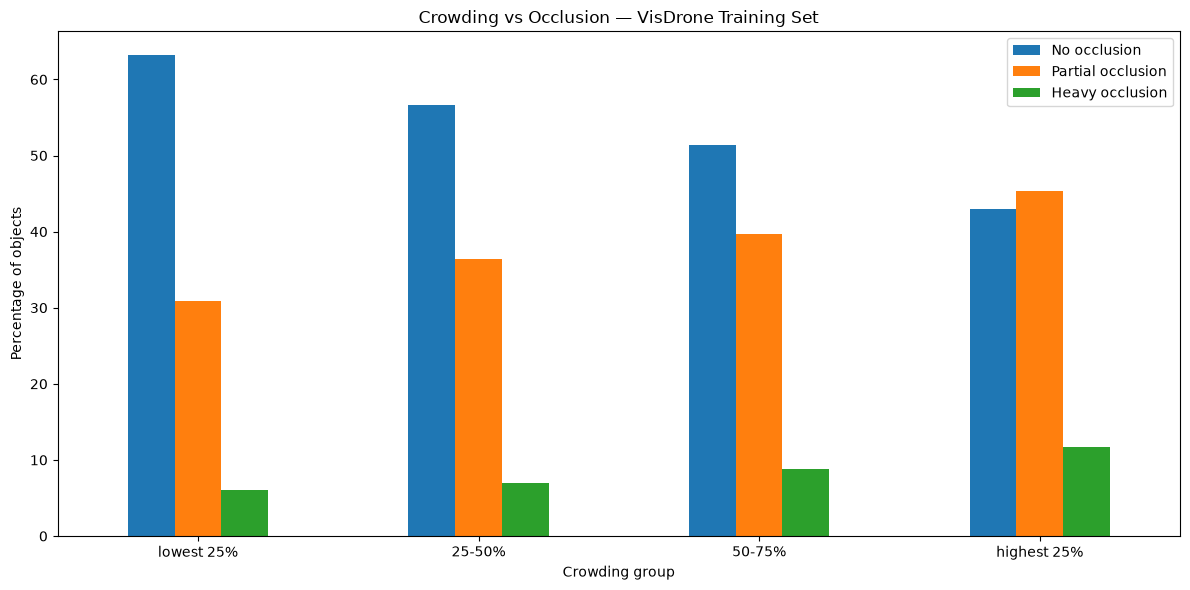

In [107]:
crowding_occlusion.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Crowding group")
plt.ylabel("Percentage of objects")
plt.title("Crowding vs Occlusion — VisDrone Training Set")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Dataset Characterization — Preliminary Findings

## Dataset Scale
- Training images: 6,471
- Valid non-ignored objects: 344,736
- Ignored regions: 8,813
- Degenerate zero-area annotations: 1

## Object Size
- Median bounding-box area: 680 px²
- Median width: 25 px
- Median height: 27 px
- Median relative image area: 0.0463%

## Crowding
- Average objects per image: 53.27
- Maximum objects in one image: 902

## Occlusion and Truncation
- Partial/heavy occlusion: 51.25%
- Partial truncation: 3.90%

## Preliminary Observations
1. VisDrone contains substantial variation in object size.
2. Human-related categories tend to have smaller bounding boxes than larger vehicle categories.
3. Highly crowded images tend to contain smaller objects.
4. Highly crowded images also contain a greater proportion of occluded objects.
5. Object size and occlusion do not show a simple monotonic relationship.

## Research Caution
These observations describe the dataset. They do not yet demonstrate which factors cause detector failures. That requires baseline model evaluation and error analysis.